### Step 03 - Cluster echo-types into echo-classes

In [27]:
# define root folder
import os
from pathlib import Path

HERE = Path(os.getcwd()).parent

In [28]:
import xarray as xr

library_path = HERE / "private/data/echotypes_libs/A2_3F_Misc.nc"
lib_ds: xr.Dataset = xr.open_dataset(library_path, chunks={"obs": 10_000})

valid_obs = ((lib_ds.depth <= 250.) & (lib_ds.Sv != -150.)).obs.values
lib_ds = lib_ds.isel(obs=valid_obs)
lib_ds

<xarray.Dataset> Size: 180MB
Dimensions:            (obs: 3463469, echotype: 235, channel: 4)
Coordinates:
    latitude           (obs) float64 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude          (obs) float64 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
    time               (obs) datetime64[ns] 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
    depth              (obs) float64 28MB dask.array<chunksize=(10000,), meta=np.ndarray>
    echotype           (obs) int32 14MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * channel            (channel) float64 32B 38.0 70.0 120.0 200.0
Dimensions without coordinates: obs
Data variables:
    shape_id           (echotype) object 2kB dask.array<chunksize=(235,), meta=np.ndarray>
    clustering_method  (echotype) object 2kB dask.array<chunksize=(235,), meta=np.ndarray>
    echotype_id        (echotype) int32 940B dask.array<chunksize=(235,), meta=np.ndarray>
    cluster_id         (echotype) int32 940B dask.array<chunksize=(235,), meta=np.ndarray>
    Sv                 (channel, obs) float32 55MB dask.array<chunksize=(4, 10000), meta=np.ndarray>
Attributes:
    echotype_library_name:  A2_3F_Misc
    ei_id:                  2
    cruise_name:            ABRACOS02
    description:            Sparse echotype Sv observations

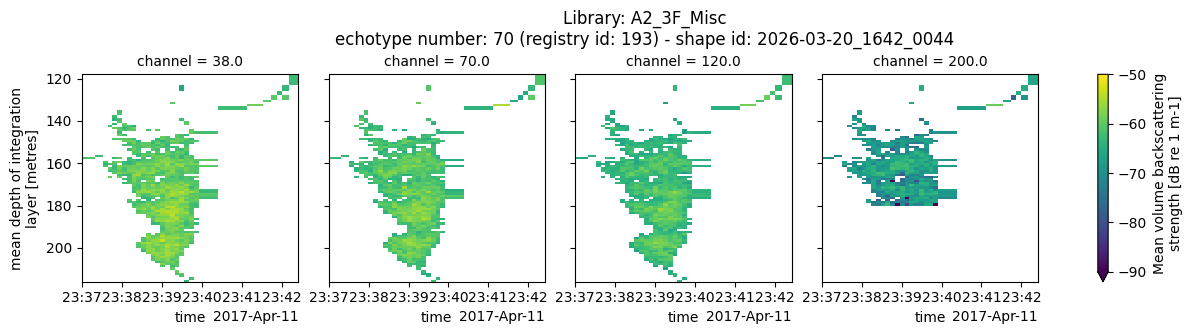

In [46]:
import numpy as np

e = np.random.choice(np.unique(lib_ds.echotype), size=1).item()

echotype_sv: xr.DataArray = (
    lib_ds
    .Sv
    .load()
    .where(lib_ds.echotype==e, drop=True)
    .set_index(obs=["time", "depth"])
    .unstack("obs")
)

g = echotype_sv.plot(x="time", yincrease=False, col='channel', col_wrap=4, vmin=-90, vmax=-50)

g.fig.suptitle(f"Library: {lib_ds.attrs.get('echotype_library_name')}"
               f"\nechotype number: {e}"
               f" (registry id: {lib_ds.echotype_id.sel(echotype=e).values.item()})"
               f" - shape id: {lib_ds.shape_id.sel(echotype=e).values.item()}",
               y=1.1);

**Building features**

In [30]:
# Simple features: mean Sv differences
from escore.features import extract_mean_sv_diff

print("Building Sv differences dataframe...")
mean_sv_diff_df = extract_mean_sv_diff(lib_ds, frequencies=[70., 120.], ref_freq=38.)

Building Sv differences dataframe...


In [31]:
features_df = mean_sv_diff_df.drop("n_obs", axis=1)

**Cluster features to classify echotypes into echoclasses**

In [32]:
from escore.echoclasses import EchoclassClassifier

classifier = EchoclassClassifier()
classifier.fit(features_df)

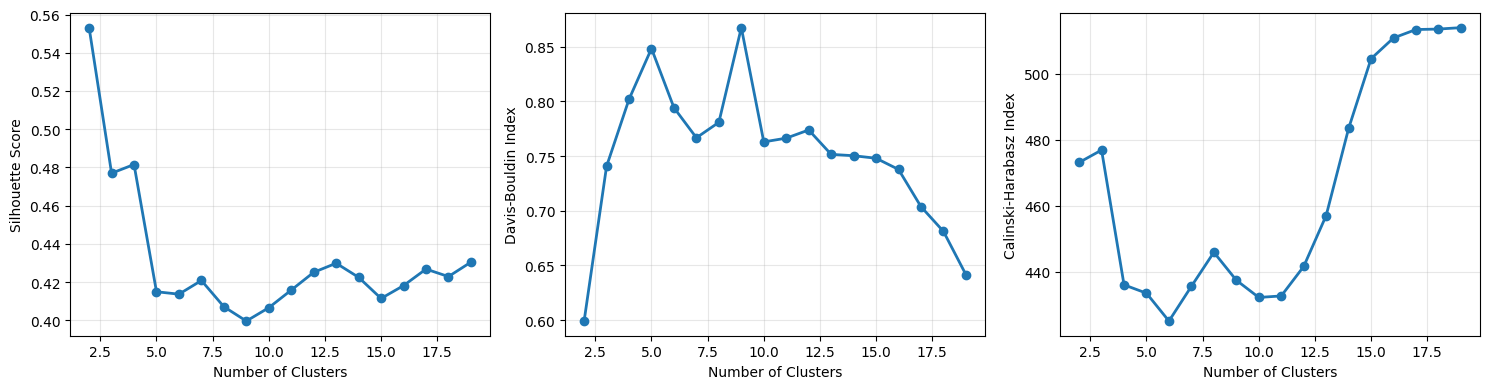

In [33]:
from escore.echoclasses import evaluate_n_clusters, plot_cluster_evaluation

metrics_df = evaluate_n_clusters(features_df, classifier, n_clusters_range=range(2, 20))
plot_cluster_evaluation(metrics_df, layout='tight');

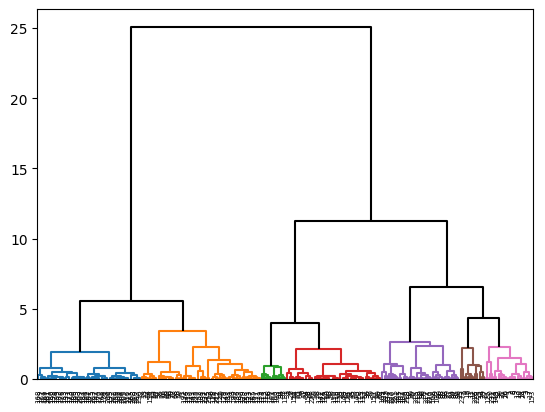

In [34]:
N_CLUSTERS = 7
dend = classifier.get_dendrogram(n_clusters=N_CLUSTERS)

In [35]:
import palettable
from matplotlib.colors import ListedColormap

classes_cmap = ListedColormap(palettable.cartocolors.qualitative.Vivid_10_r.mpl_colors[:N_CLUSTERS])


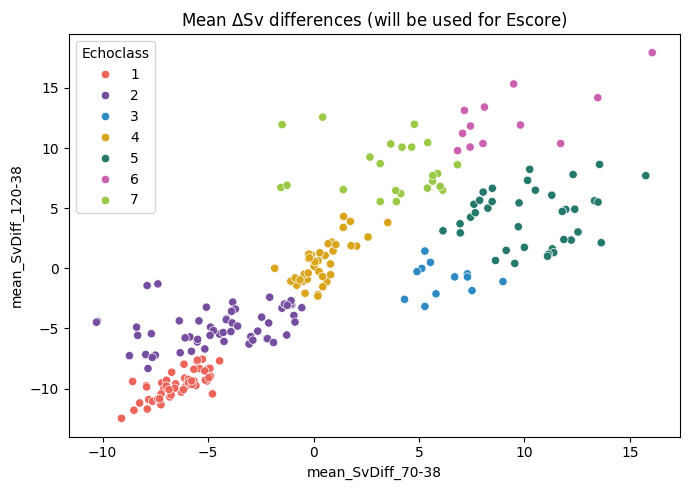

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

features_df["label"] = classifier.predict(n_clusters=N_CLUSTERS)

fig, ax = plt.subplots(figsize=(7, 5), layout="tight")

sns.scatterplot(
    features_df,
    x="mean_SvDiff_70-38", 
    y="mean_SvDiff_120-38", 
    hue="label",
    palette=classes_cmap,
    ax=ax
)
ax.set_title(r"Mean $\Delta$Sv differences (will be used for Escore)")
ax.legend(title="Echoclass");

In [37]:
from escore.echoclasses import validate_classification

features_df["label"] = classifier.predict(n_clusters=N_CLUSTERS)

results = validate_classification(features_df)
print(results['classification_report'])

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        17
           2       0.94      1.00      0.97        15
           3       1.00      0.80      0.89         5
           4       1.00      0.88      0.93         8
           5       0.94      1.00      0.97        15
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00         7

    accuracy                           0.97        71
   macro avg       0.98      0.95      0.97        71
weighted avg       0.97      0.97      0.97        71



### Step 04 - Compute ellipses

In [38]:
from escore.ellipses import make_ellipses

method = "equal"

ellipses_df = make_ellipses(
    lib_ds,
    labels=classifier.predict(n_clusters=N_CLUSTERS),
    echotypes=features_df.index.values,
    frequencies=[70., 120.],
    ref_freq=38.,
    weight_method=method,
    confidence=0.3
)

In [39]:
# Create colormap for echoclasses
from matplotlib.colors import ListedColormap, rgb_to_hsv, hsv_to_rgb
import matplotlib as mpl

VMIN, VMAX = -90., -50.

class_colors_dict = {}

for echoclass in features_df['label'].unique():
    #print(f"Computing mean hue for echoclass: {echoclass}")
    echotypes_list = features_df[features_df['label'] == echoclass].index.values
    mean_sv = (
        lib_ds
        .where(lib_ds.echotype.isin(echotypes_list), drop=True)
        .Sv
        .mean(dim="obs")
        .sel(channel=[38., 70., 120.])
        .compute()
    )
    rgb = np.clip((mean_sv.values - VMIN) / (VMAX - VMIN), 0, 1)

    # Max luminance for cmap
    hsv = rgb_to_hsv(rgb.reshape(1, 1, 3)).reshape(3)
    hsv[2] = 0.75
    rgb_bright = hsv_to_rgb(hsv.reshape(1, 1, 3)).reshape(3)

    r, g, b = rgb_bright

    class_colors_dict[echoclass] = (r, g, b)

colors = [class_colors_dict[echoclass] for echoclass in sorted(list(class_colors_dict.keys()))]
rgb_cmap = ListedColormap(colors)
mpl.colormaps.register(cmap=rgb_cmap, force=True)

/var/folders/mr/p37q64sn0fj06kw8cghzs3v40000gn/T/ipykernel_47787/4287959895.py:33: UserWarning: Overwriting the cmap 'from_list' that was already in the registry.
  mpl.colormaps.register(cmap=rgb_cmap, force=True)


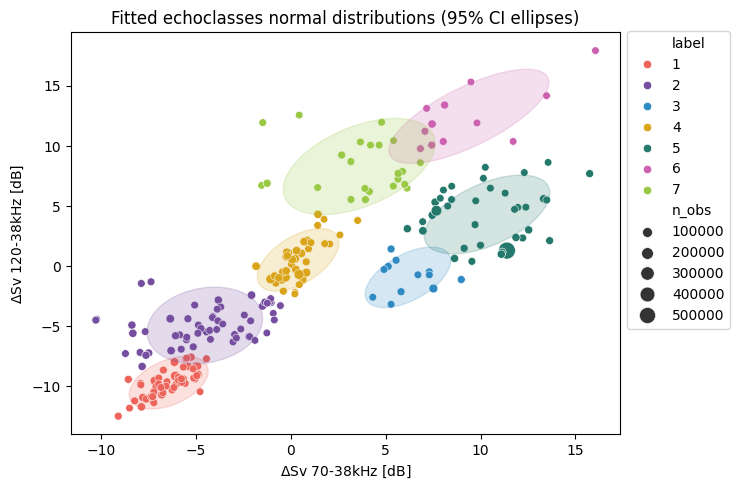

In [40]:
import pandas as pd
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(1, 1, figsize=(7.5, 5), layout="tight")

joined_df = pd.merge(features_df, mean_sv_diff_df[["n_obs"]], how="inner", on="echotype")

sns.scatterplot(
    joined_df,
    x="mean_SvDiff_70-38", 
    y="mean_SvDiff_120-38",
    size="n_obs",
    sizes=(30, 150),
    hue="label",
    palette=classes_cmap,#rgb_cmap,
    legend="brief",
    ax=ax
)

ax.legend(bbox_to_anchor=(1., 1.02))
ax.set_xlabel(r"$\Delta$Sv 70-38kHz [dB]")
ax.set_ylabel(r"$\Delta$Sv 120-38kHz [dB]")

for i, row in ellipses_df.iterrows():

    ellipse = Ellipse(
        xy=row["center"],
        width=2 * row["semi_major"], 
        height=2 * row["semi_minor"],
        angle=row["angle"],
        facecolor=classes_cmap.colors[i],
        edgecolor=classes_cmap.colors[i],
        alpha=0.2,
    )
    ax.add_patch(ellipse)

ax.set_title(r"Fitted echoclasses normal distributions (95% CI ellipses)");

### Compute distance to ellipses

In [42]:
from escore import EscoreClassifier

# Fetch ellipsoids data
classes         = ellipses_df["class"].values
cov_matrices    = np.stack(ellipses_df["cov"].values)
centers         = np.stack(ellipses_df["center"].values)

# Instanciate classifier
escore = EscoreClassifier(classes, centers, cov_matrices)

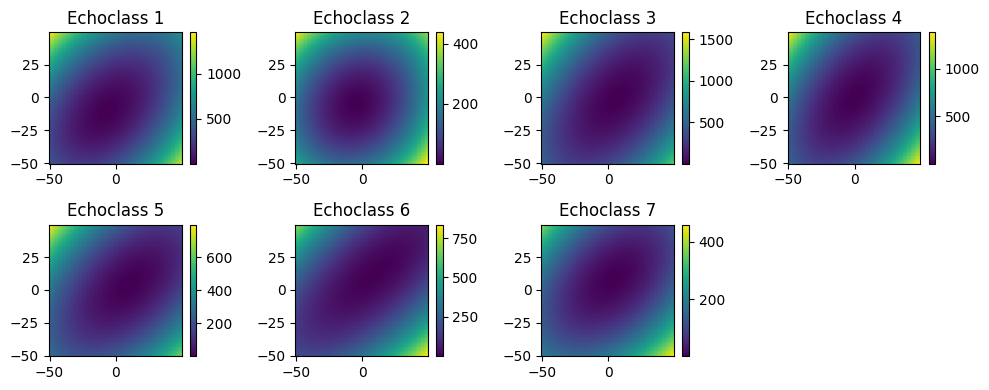

In [43]:
transform = 'none'
fig, axes = escore.diagnostics.show_scores_2D(transform=transform, figsize=(10, 4))

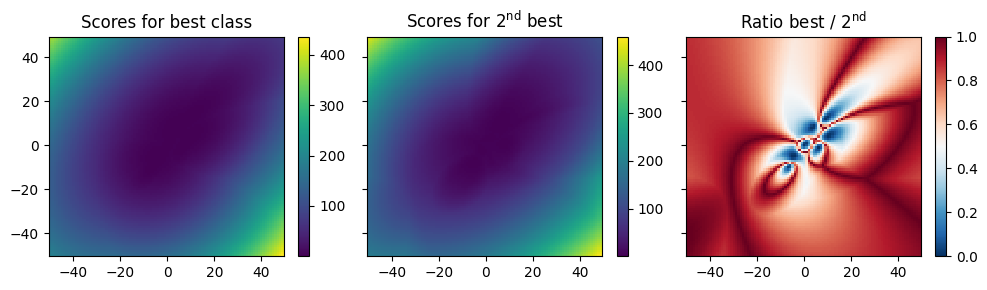

In [44]:
fig, axes = escore.diagnostics.best_to_second_plot_2D(transform=transform, figsize=(10, 3))

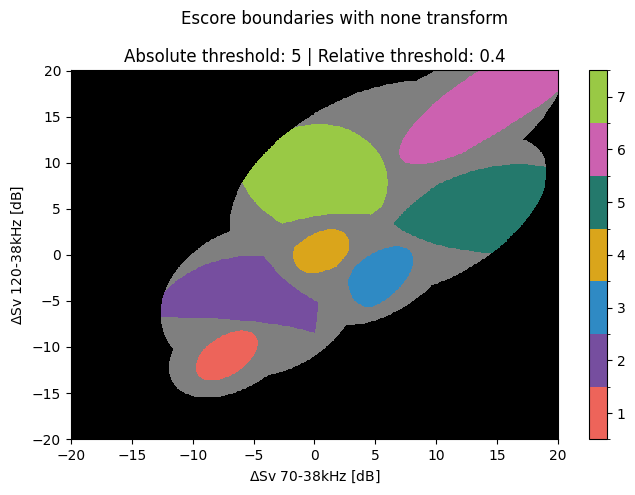

In [45]:
default_thresholds = escore.transforms_dict[transform].default_thresholds

fig, ax, results = escore.diagnostics.boundaries_plot_2D(
    x_values=np.linspace(-20, 20, 500),
    y_values=np.linspace(-20, 20, 500),
    absolute_threshold=5,#default_thresholds["absolute"],
    relative_threshold=0.4,#default_thresholds["relative"],
    transform=transform,
    figsize=(7, 5),
    cmap=classes_cmap,    
)
ax.set_xlabel(r"$\Delta$Sv 70-38kHz [dB]")
ax.set_ylabel(r"$\Delta$Sv 120-38kHz [dB]")
fig.suptitle(f'Escore boundaries with {transform} transform');

### Predict on `xarray`

In [31]:
from matplotlib.dates import ConciseDateFormatter
from matplotlib.axes import Axes
from matplotlib.collections import QuadMesh
import matplotlib.pyplot as plt
from typing import Tuple, Any

def plot_rgb_colormesh(
    ax: Axes, 
    sv: xr.DataArray, 
    vmin: float = -90, 
    vmax: float = -50, 
    show_title: bool=False
) -> Tuple[QuadMesh, Any]:
    """
    Plots the RGB echogram as a colormesh. The 3 channels of sv are mapped to red, green, and blue.
    """

    time = sv.time.values
    depth = sv.depth.values
    channels = sv.channel.values

    X, Y = np.meshgrid(time, depth)

    if not len(sv.channel) == 3:
        raise ValueError(f"sv must have exactly 3 channels for RGB mapping.")

    # Convert to RGB
    sv = sv.transpose("depth", "time", "channel") # transpose to shape (H, W, C) for pcolormesh
    Z = np.clip((sv-vmin)/(vmax-vmin), 0, 1)
    Z = np.nan_to_num(Z, nan=0.0)   # this handles frequency channels range limits

    # Mask invalid data (mostly bottom)
    valid_data_mask = ~np.all(np.isnan(sv), axis=-1)
    Z = np.ma.array(Z, mask=np.dstack([~valid_data_mask]*3))

    im = ax.pcolormesh(X, Y, Z, vmin=vmin, vmax=vmax, shading='nearest')
    if show_title:
        ax.set_title(f"R: {channels[0]} kHz | G: {channels[1]} kHz | B: {channels[2]} kHz")
    ax.xaxis.set_major_formatter(ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.yaxis.set_inverted(True)
    ax.set_ylabel('depth [m]')
    ax.set_xlabel(f'time')
    
    return im, valid_data_mask

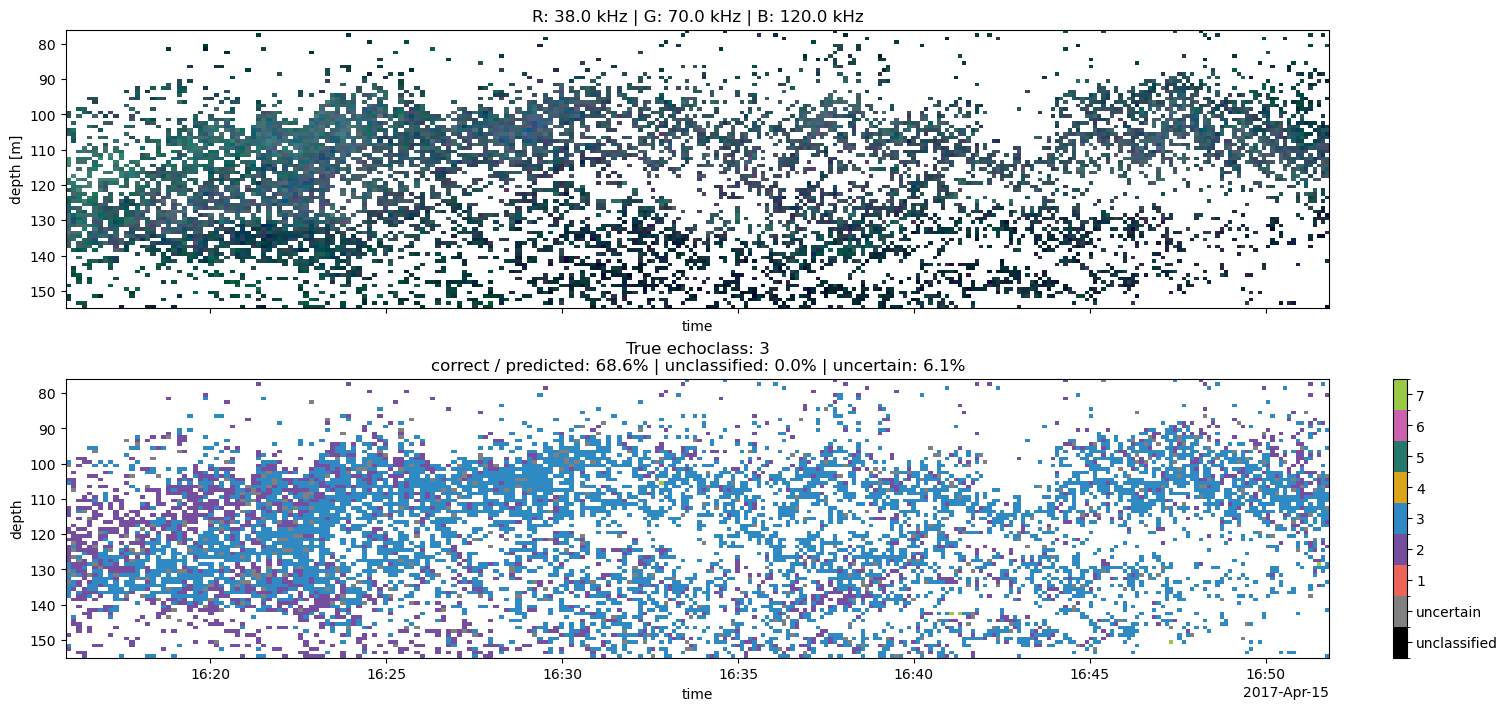

In [186]:
from matplotlib.colors import ListedColormap, BoundaryNorm

PLOT_CHECKS = False
PLOT_CLASSIF = True

# Sample random echotype from library
e = np.random.choice(np.unique(lib_ds.echotype), size=1).item()
#e = 71

echotype_sv: xr.DataArray = (
    lib_ds.Sv
    .where(lib_ds.echotype==e, drop=True)
    .set_index(obs=["time", "depth"])
    .unstack("obs")
    .sel(channel=[38., 70., 120.])
)

# Display echotype Sv
if PLOT_CHECKS:
    echotype_sv.plot(
        x='time',
        col="channel",
        yincrease=False,
        vmin=-90.,
        vmax=-50.
    )
    plt.gcf().set_size_inches(15, 5)

# Select frequency channels and compute delta Sv 38. (like for model)
X = echotype_sv.sel(channel=[70., 120.]) - echotype_sv.sel(channel=38.)

# Test simple Escore
scores: xr.DataArray = escore.get_scores(X, features_dim_name="channel")

# Show scores for each echoclass
if PLOT_CHECKS:
    scores.plot(x='time', col='echoclass', col_wrap=5, yincrease=False)

# Predict
X = echotype_sv.sel(channel=[70., 120.]) - echotype_sv.sel(channel=38.)     # transform to delta Sv (70- 38 and 120-38 - same order as training)

results = escore.predict(
    X,
    transform=transform,
    absolute_threshold=default_thresholds["absolute"],
    relative_threshold=default_thresholds["relative"],
    features_dim_name="channel"
)

preds_idx = results["predicted_class_idx"]
unclassified = results["absolute_threshold_mask"]
uncertain = results["relative_threshold_mask"]

preds_idx = preds_idx.where(~unclassified, -2)
preds_idx = preds_idx.where(~uncertain, -1)

# Compare predictions to the echotype's echoclass
true_class = features_df.loc[[e]].label.item()

true_preds = (preds_idx == list(escore.classes).index(true_class)).sum()
n_uncertain = (preds_idx == -1).sum()
n_unclassified = (preds_idx == -2).sum()
n_classified = (~np.isnan(preds_idx)).sum()
n_tot = n_classified + n_uncertain + n_unclassified

correct_of_predicted = true_preds / n_classified
uncertain_of_tot = n_uncertain / n_tot
unclassified_of_tot = n_unclassified / n_tot

if PLOT_CLASSIF:

    fig, axes = plt.subplots(nrows=2, figsize=(15, 7), sharex=True, layout='constrained')

    # RGB plot of echogram
    plot_rgb_colormesh(axes[0], echotype_sv, show_title=True)

    n_classes = len(escore.classes)

    #cmap_str = "tab20"
    #colors = ["black", "grey"] + list(plt.get_cmap(cmap_str).colors[:n_classes])
    colors = ["black", "grey"] + classes_cmap.colors
    boundaries = np.arange(-2.5, n_classes + 0.5, 1)

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries, ncolors=len(colors))

    im = preds_idx.plot(
        x="time",
        yincrease=False, 
        cmap=cmap, 
        norm=norm,
        ax=axes[1],
    )
    cbar = im.colorbar
    cbar.set_label(None)
    cbar.set_ticks([-2, -1] + list(range(len(escore.classes))))
    cbar.set_ticklabels(["unclassified", "uncertain"] + list(escore.classes))
    #plt.gcf().set_size_inches(10, 4)
    plt.title(f"True echoclass: {true_class}\ncorrect / predicted: {correct_of_predicted:.1%} | unclassified: {unclassified_of_tot:.1%} | uncertain: {uncertain_of_tot:.1%}")

### Predict on full data

In [ ]:
from packages.escore.dataloader import load_dataset

ds = load_dataset(HERE / "private/data/input/Abracos_A2/", chunks={"time": 10_000, "depth": 200})
ds = ds.where(ds.Sv != -150.)
delta_sv = ds.Sv.sel(channel=[70., 120.]) - ds.Sv.sel(channel=38.)

# Predict lazily (need to .compute() to have actual results)
results = escore.predict(
    delta_sv,
    transform=transform,
    absolute_threshold=5, #default_thresholds["absolute"],
    relative_threshold=0.4, #default_thresholds["relative"],
    features_dim_name="channel",
    compute_dask=False
)

preds_idx = results["predicted_class_idx"]
unclassified = results["absolute_threshold_mask"]
uncertain = results["relative_threshold_mask"]

preds_idx = preds_idx.where(~unclassified, -2)
preds_idx = preds_idx.where(~uncertain, -1)

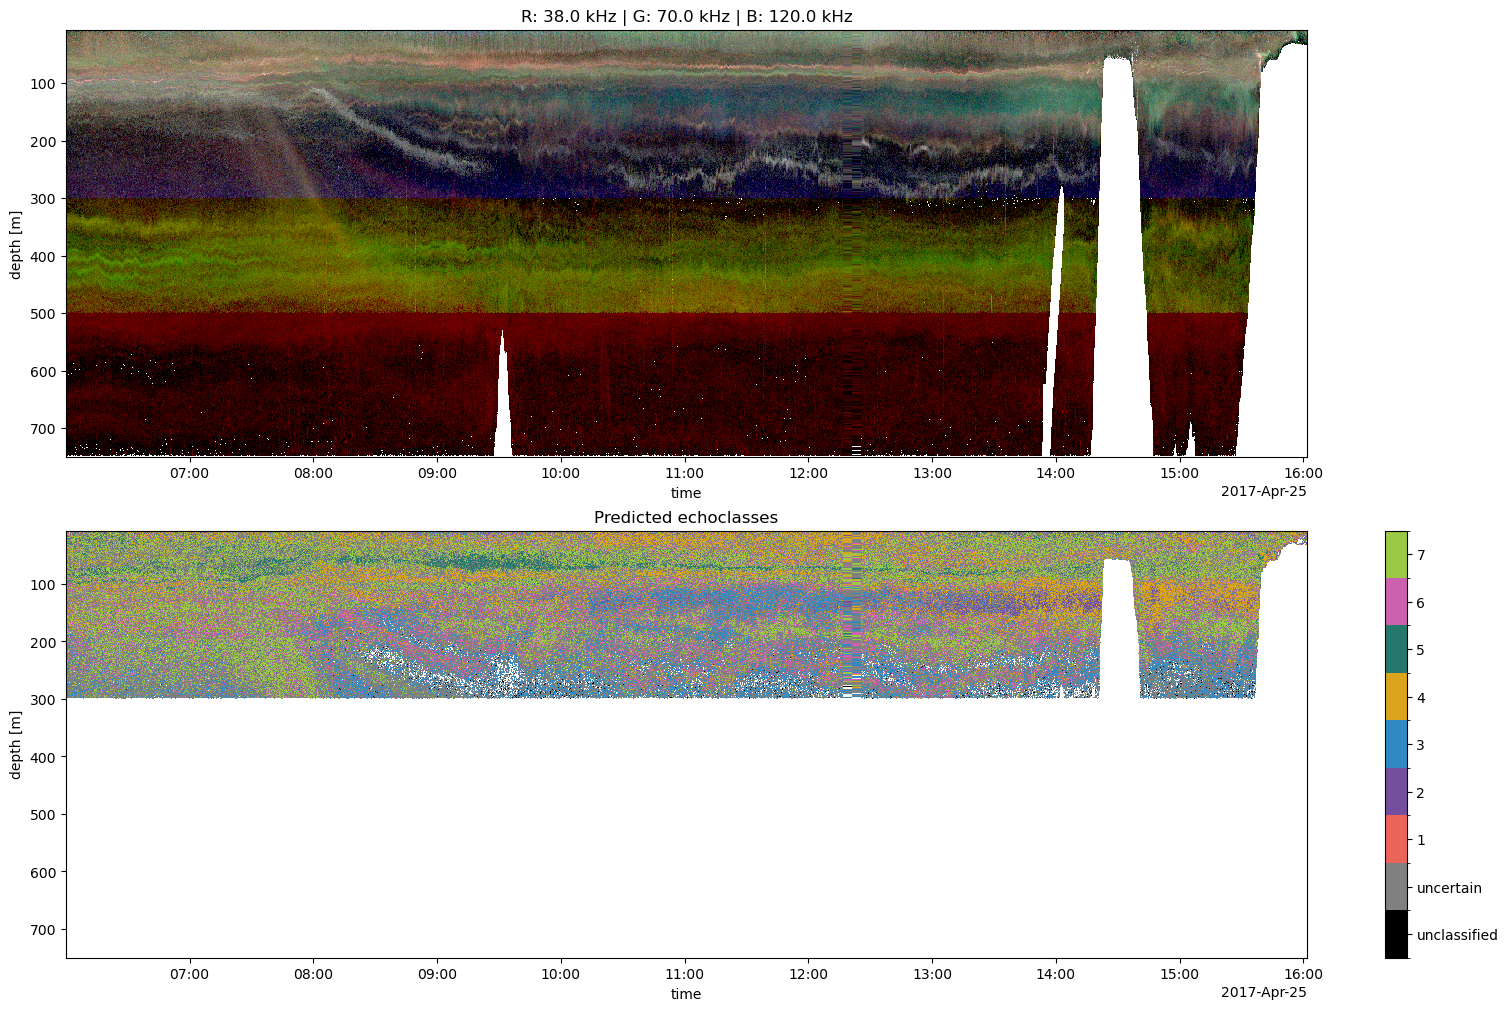

In [223]:
# Plot a 1-day prediction with xarray.plot & RGB plot for comparison

fig, axes = plt.subplots(nrows=2, figsize=(15, 10), layout='constrained', sharex=False)

VMIN = -150.
DAY = '2017-04-25'
time_slice = slice(f'{DAY} 06:00', f'{DAY} 18:00')

# RGB plot
sv = (
    ds
    .Sv
    .sel(time=time_slice, channel=[38., 70., 120.])
)

plot_rgb_colormesh(axes[0], sv, show_title=True)

# Class id prediction
preds_formatted = (
    preds_idx
    .where(ds.Sv.min(dim="channel") > VMIN, np.nan)
    .sel(time=time_slice)
    .compute()
)

im = preds_formatted.plot(
    x="time",
    yincrease=False,
    cmap=cmap, 
    norm=norm,
    cbar_kwargs=dict(label="echoclass_idx", ticks=np.arange(-2, n_classes)),
    ax=axes[1]
)
cbar = im.colorbar
cbar.set_label(None)
cbar.set_ticks([-2, -1] + list(range(len(escore.classes))))
cbar.set_ticklabels(["unclassified", "uncertain"] + list(escore.classes))
axes[1].set_ylabel("depth [m]")

axes[1].set_title(
    "Predicted echoclasses"
    #f" (transform = {transform} | E = {results['params']['absolute_threshold']} | Q = {results['params']['relative_threshold']} | min Sv > {VMIN} dB)"
);
#fig.suptitle("Comparison of Escore predictions with RGB echogram");
plt.savefig(HERE/"private/figures/echogram_predictions.png", dpi=300)

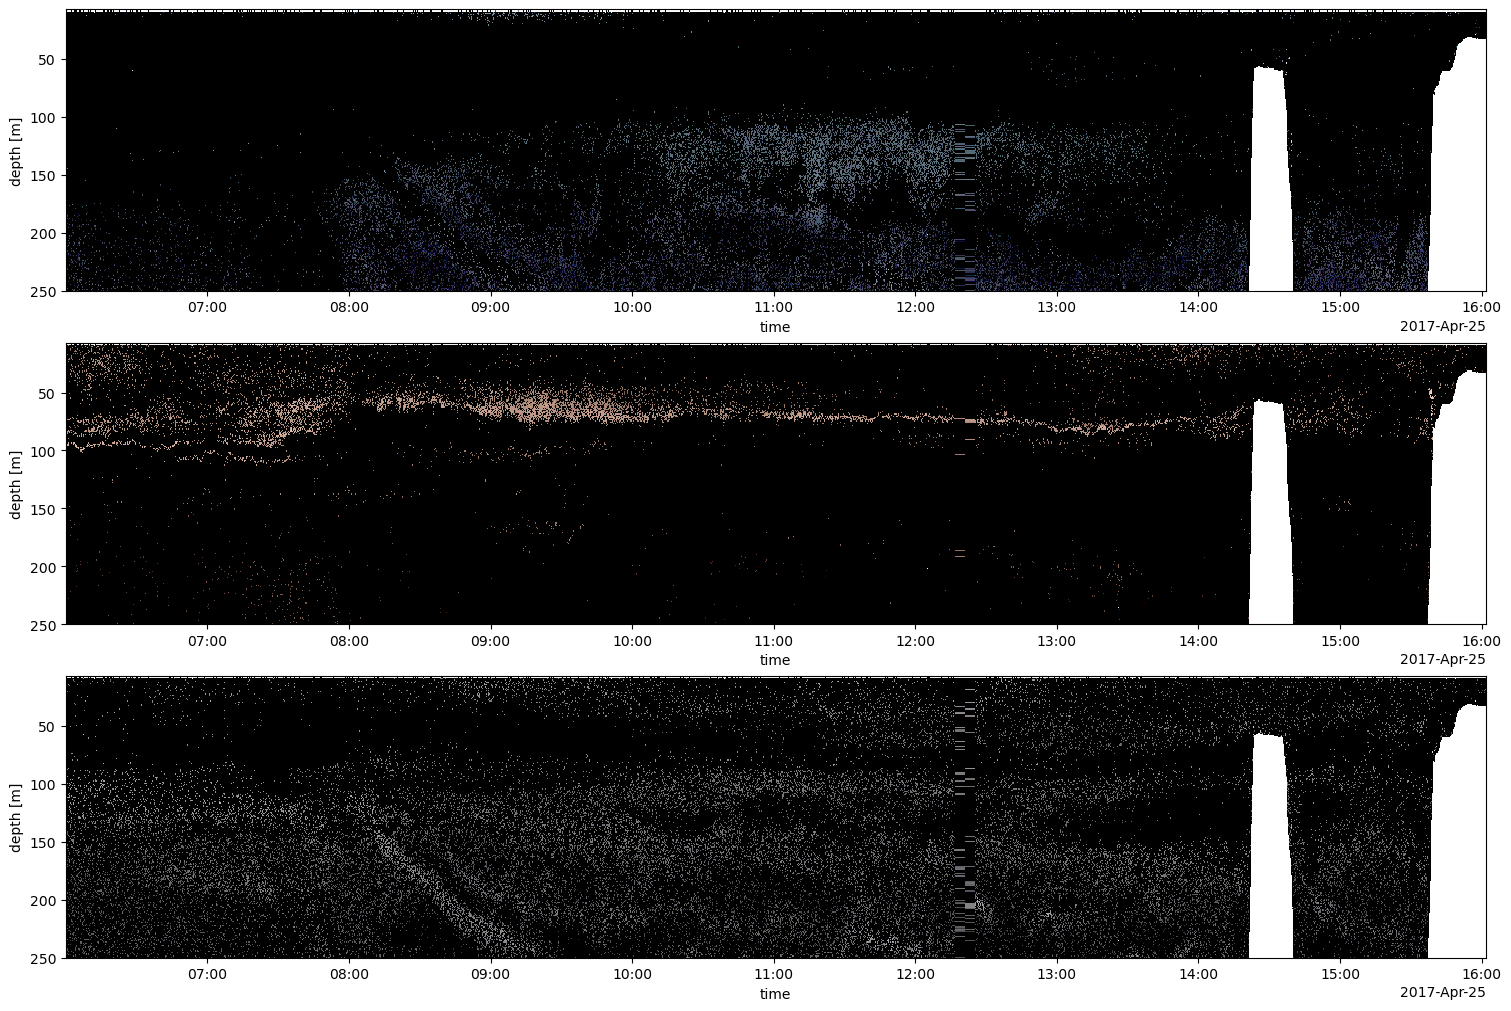

In [224]:
# Plot a class & the certainty

fig, axes = plt.subplots(nrows=3, figsize=(15, 10), layout='constrained')

CLASS_IDX = [2, 4, 5]

depth_slice = slice(None, 250)

for i, class_idx in enumerate(CLASS_IDX):
    class_mask = (    
        (preds_idx == class_idx)
        .where(ds.Sv.min(dim="channel") > VMIN, False)
        .sel(time=time_slice, depth=depth_slice)
    )

    sv_sub = (
        ds
        .Sv
        .sel(time=time_slice, depth=depth_slice, channel=[38., 70., 120.])
        .transpose("depth", "time", "channel")
    )

    sv_class = sv_sub.where(class_mask, np.nan)

    # RGB plot
    im, valid_mask = plot_rgb_colormesh(axes[i], sv_class, vmin=-100.)

    time = sv_sub.time.values
    depth = sv_sub.depth.values
    X, Y = np.meshgrid(time, depth)

    # Mask not class as black
    class_mask_array = class_mask.transpose("depth", "time").values
    not_class_mask_ma = np.ma.array(~class_mask_array, mask=class_mask_array)
    axes[i].pcolormesh(X, Y, not_class_mask_ma, cmap='Greys_r', shading="nearest")

    # Mask bottom / all nans as white
    invalid_mask = np.all(np.isnan(sv_sub), axis=-1).values
    invalid_mask_ma = np.ma.array(invalid_mask, mask=~invalid_mask)
    axes[i].pcolormesh(X, Y, invalid_mask_ma, cmap='Greys', shading="nearest")

plt.savefig(HERE/"private/figures/3_echoclasses_RGB.png", dpi=300)

In [ ]:
# Save predictions as .nc file
# VMIN = -90.

# (
#     preds_idx
#     .where(
#         ds.Sv.min(dim="channel") > VMIN,
#         np.nan
#     )
#     .to_netcdf(HERE/"private/predictions/preds.nc")
# )